# Resultados Fase 1 — Ocupado / Parado / Inactivo

Dos etapas (solo demografía): Activo vs Inactivo y, sobre activos, Ocupado vs Parado. Luego se encadenan con los umbrales F1.

Figuras: `reports/figures/fase1/`. Números: `reports/fase1/comparacion_modelos.json`.

La demografía va bien para la participación (PR-AUC ~0,94) y mal para separar paro y ocupación (PR-AUC ~0,27).


## 1. Métricas y comparación de modelos

Carga lo que dejó `run_model_fase1.py`.


In [1]:
import json
from pathlib import Path

from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "modelado":
    ROOT = ROOT.parents[1]
elif ROOT.name == "notebooks":
    ROOT = ROOT.parent

with open(ROOT / "reports/fase1/comparacion_modelos.json", encoding="utf-8") as f:
    comp = json.load(f)
with open(ROOT / "reports/memoria/metricas_maestras.json", encoding="utf-8") as f:
    maestras = json.load(f)

cfg = comp["config_busqueda"]
a, b = comp["etapa_a"], comp["etapa_b"]
comb = maestras["fase1"]["combinado_umbrales_calibrados"]

print("=== CONFIGURACIÓN ===")
print(f"Búsqueda HP: n_iter={cfg['n_iter']}, muestra={cfg['tamano_muestra']:,}, CV={cfg['cv_folds']}")
print(f"Split temporal: train ≤ {maestras['corte_temporal']['train_hasta']} · test ≥ {maestras['corte_temporal']['test_desde']}")
print()

for etapa, key in [("A — Activo vs Inactivo", "etapa_a"), ("B — Ocupado vs Parado", "etapa_b")]:
    e = comp[key]
    gan = e["ganador"]
    m = e["comparacion"][gan]
    bl = e["comparacion"]["baseline_prevalencia"]
    opt = e["metricas_test_umbral_optimo"]
    print(f"=== Etapa {etapa} ===")
    print(f"Ganador: {gan}")
    print(f"PR-AUC test: {m['pr_auc']:.4f}  |  ROC-AUC: {m['roc_auc']:.4f}  |  F1 @0.50: {m['f1']:.4f}")
    print(f"Baseline PR-AUC: {bl['pr_auc']:.4f}")
    print(f"Umbral F1 (train): {e['umbral_optimo_f1_train']:.3f}  →  F1 test: {opt['f1']:.4f}")
    print()

print("=== Combinado A→B (umbrales calibrados) ===")
print(f"Accuracy: {comb['accuracy']:.2f}")
print(f"F1 Inactivo: {comb['f1_inactivo']:.2f}  |  F1 Ocupado: {comb['f1_ocupado']:.2f}  |  F1 Parado: {comb['f1_parado']:.2f}")
print(f"Macro-F1 aprox.: {comb['macro_f1_aprox']:.2f}")

informe = ROOT / "reports/fase1/informe_final.txt"
if informe.exists():
    display(Markdown("### Informe de clasificación (test)\n\n```\n" + informe.read_text(encoding="utf-8") + "\n```"))


=== CONFIGURACIÓN ===
Búsqueda HP: n_iter=20, muestra=120,000, CV=3
Split temporal: train ≤ 2024T4 · test ≥ 2025T1

=== Etapa A — Activo vs Inactivo ===
Ganador: random_forest
PR-AUC test: 0.9380  |  ROC-AUC: 0.8575  |  F1 @0.50: 0.8567
Baseline PR-AUC: 0.7493
Umbral F1 (train): 0.275  →  F1 test: 0.8964

=== Etapa B — Ocupado vs Parado ===
Ganador: lightgbm
PR-AUC test: 0.2731  |  ROC-AUC: 0.7532  |  F1 @0.50: 0.3145
Baseline PR-AUC: 0.1018
Umbral F1 (train): 0.625  →  F1 test: 0.3341

=== Combinado A→B (umbrales calibrados) ===
Accuracy: 0.72
F1 Inactivo: 0.61  |  F1 Ocupado: 0.83  |  F1 Parado: 0.25
Macro-F1 aprox.: 0.56


### Informe de clasificación (test)

```
MODELADO FASE 1 — Ganador Etapa A: random_forest | Ganador Etapa B: lightgbm
Búsqueda HP: n_iter=20, muestra=120000, CV=3
Umbrales calibrados (máx. F1 en train): A=0.275 | B=0.625

=== Etapa A: Activo vs Inactivo @0.50 ===
              precision    recall  f1-score   support

    Inactivo       0.57      0.73      0.64     88825
      Activo       0.90      0.82      0.86    265483

    accuracy                           0.80    354308
   macro avg       0.74      0.77      0.75    354308
weighted avg       0.82      0.80      0.80    354308

=== Etapa A @ umbral 0.275 ===
              precision    recall  f1-score   support

    Inactivo       0.76      0.50      0.61     88825
      Activo       0.85      0.95      0.90    265483

    accuracy                           0.84    354308
   macro avg       0.81      0.73      0.75    354308
weighted avg       0.83      0.84      0.82    354308


=== Etapa B: Ocupado vs Parado @0.50 ===
              precision    recall  f1-score   support

     Ocupado       0.95      0.71      0.81    238460
      Parado       0.21      0.66      0.31     27023

    accuracy                           0.71    265483
   macro avg       0.58      0.69      0.56    265483
weighted avg       0.87      0.71      0.76    265483

=== Etapa B @ umbral 0.625 ===
              precision    recall  f1-score   support

     Ocupado       0.93      0.87      0.90    238460
      Parado       0.27      0.44      0.33     27023

    accuracy                           0.82    265483
   macro avg       0.60      0.65      0.62    265483
weighted avg       0.86      0.82      0.84    265483


=== Combinado (3 clases), A -> B con umbrales calibrados ===
              precision    recall  f1-score   support

    Inactivo       0.76      0.50      0.61     88825
     Ocupado       0.81      0.84      0.83    238460
      Parado       0.19      0.34      0.25     27023

    accuracy                           0.72    354308
   macro avg       0.59      0.56      0.56    354308
weighted avg       0.75      0.72      0.73    354308


```

## 2. Comparativa rápida de candidatos (PR-AUC test)

Tabla sintética para la memoria: los tres algoritmos en cada etapa.


In [2]:
import pandas as pd

filas = []
for etapa, key in [("A", "etapa_a"), ("B", "etapa_b")]:
    for modelo, m in comp[key]["comparacion"].items():
        if modelo == "baseline_prevalencia":
            continue
        if "pr_auc" not in m:
            continue
        filas.append({
            "Etapa": etapa,
            "Modelo": modelo.replace("_", " ").title(),
            "PR-AUC": round(m["pr_auc"], 4),
            "ROC-AUC": round(m.get("roc_auc", float("nan")), 4),
            "F1 @0.50": round(m.get("f1", float("nan")), 4),
            "Ganador": "si" if comp[key]["ganador"] == modelo else "",
        })

tabla = pd.DataFrame(filas).sort_values(["Etapa", "PR-AUC"], ascending=[True, False])
display(tabla.style.hide(axis="index"))


Etapa,Modelo,PR-AUC,ROC-AUC,F1 @0.50,Ganador
A,Random Forest,0.938000,0.857500,0.856700,si
A,Lightgbm,0.937700,0.856700,0.852800,
A,Regresion Logistica,0.926400,0.835500,0.852700,
B,Lightgbm,0.273100,0.753200,0.314500,si
B,Random Forest,0.272300,0.751300,0.323500,
B,Regresion Logistica,0.241700,0.733800,0.312700,


## 3. Galería de figuras


#### `etapa_a__activo_vs_inactivo_curva_pr.png`

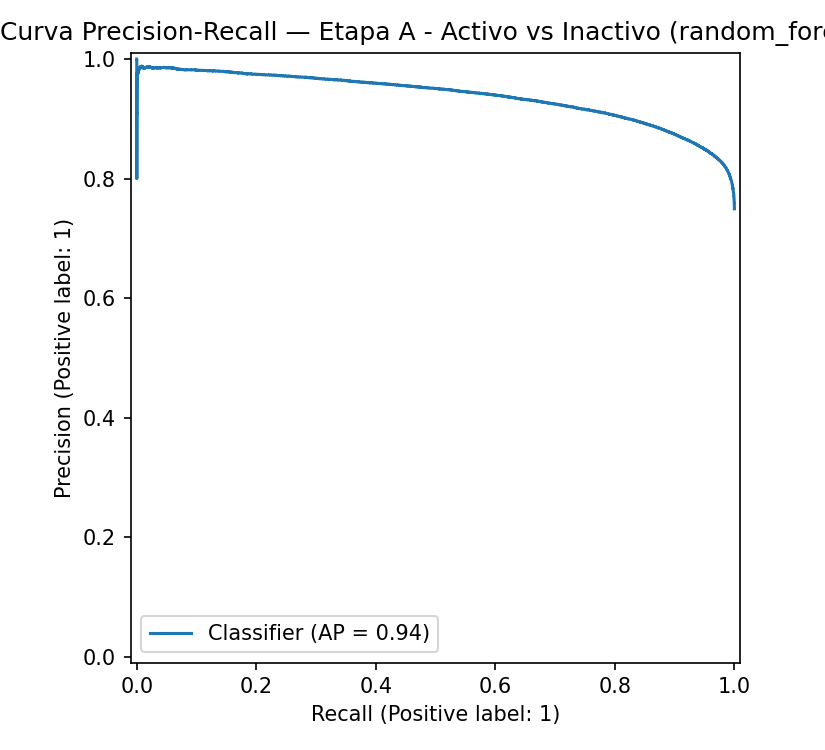

#### `etapa_a__activo_vs_inactivo_matriz_confusion.png`

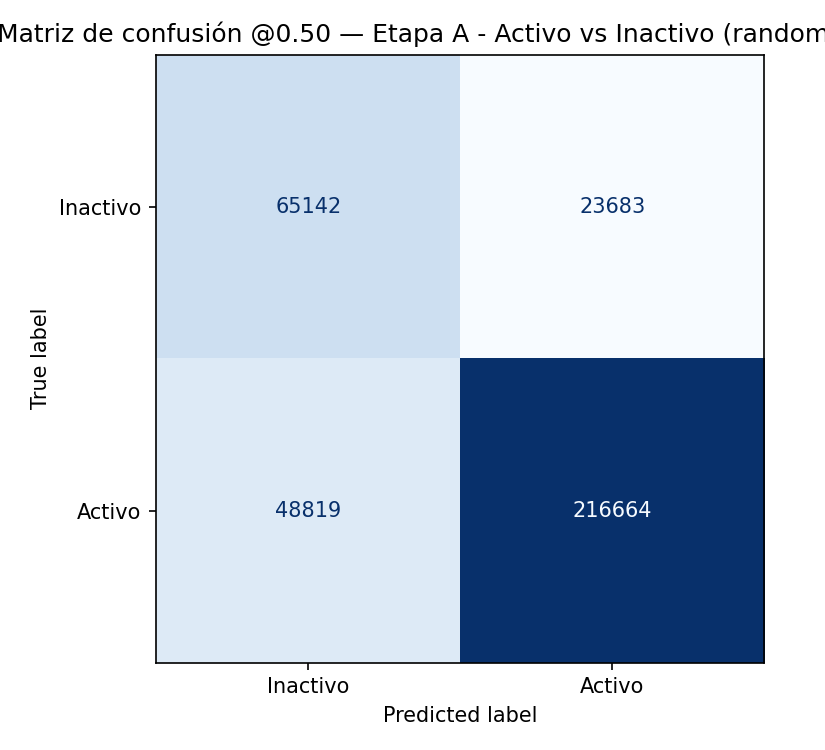

#### `etapa_a__activo_vs_inactivo_matriz_confusion_umbral_optimo.png`

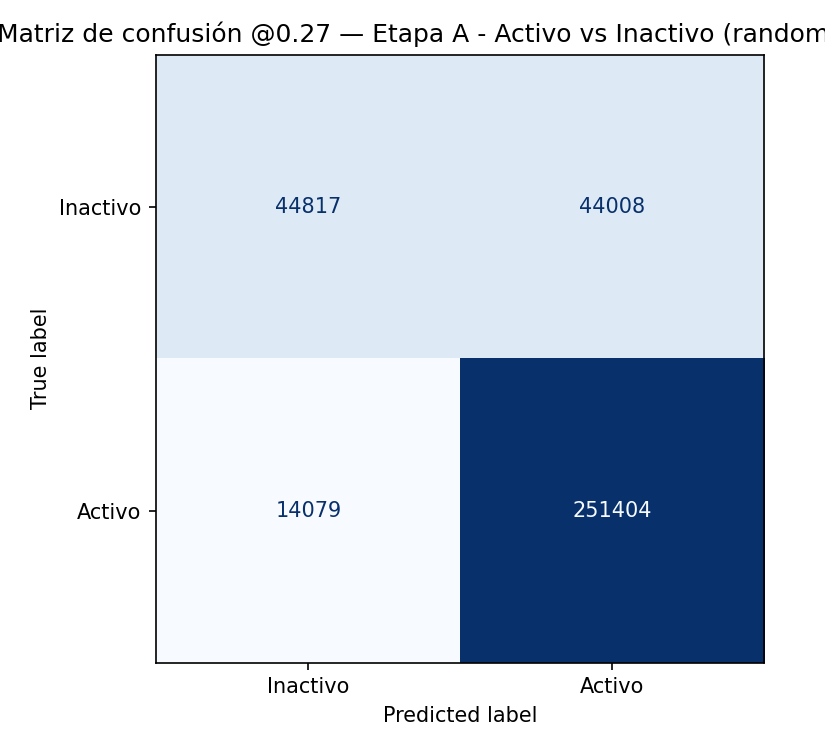

#### `etapa_a__activo_vs_inactivo_shap_summary.png`

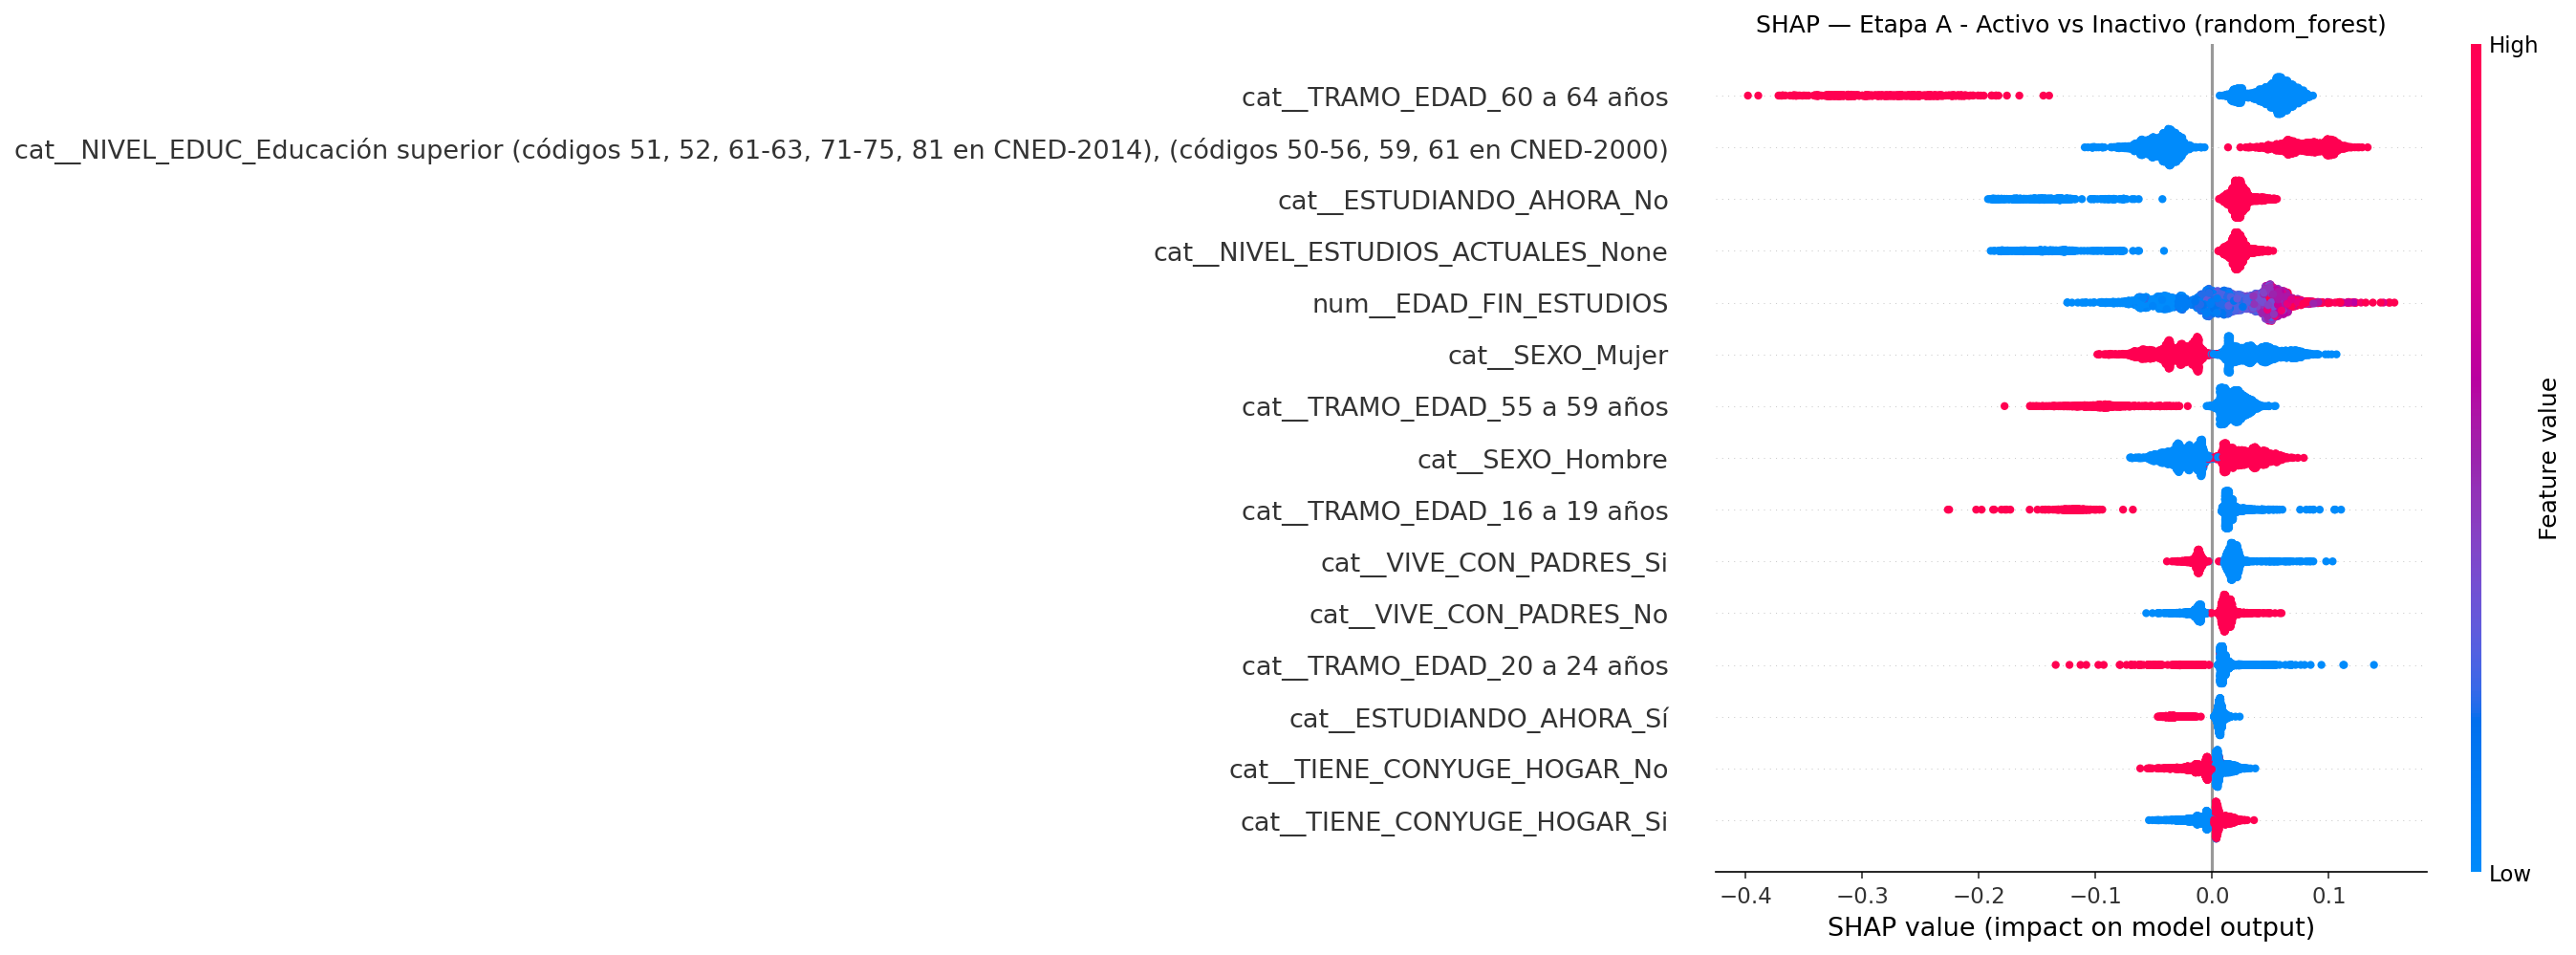

#### `etapa_a__activo_vs_inactivo_shap_importancia_barras.png`

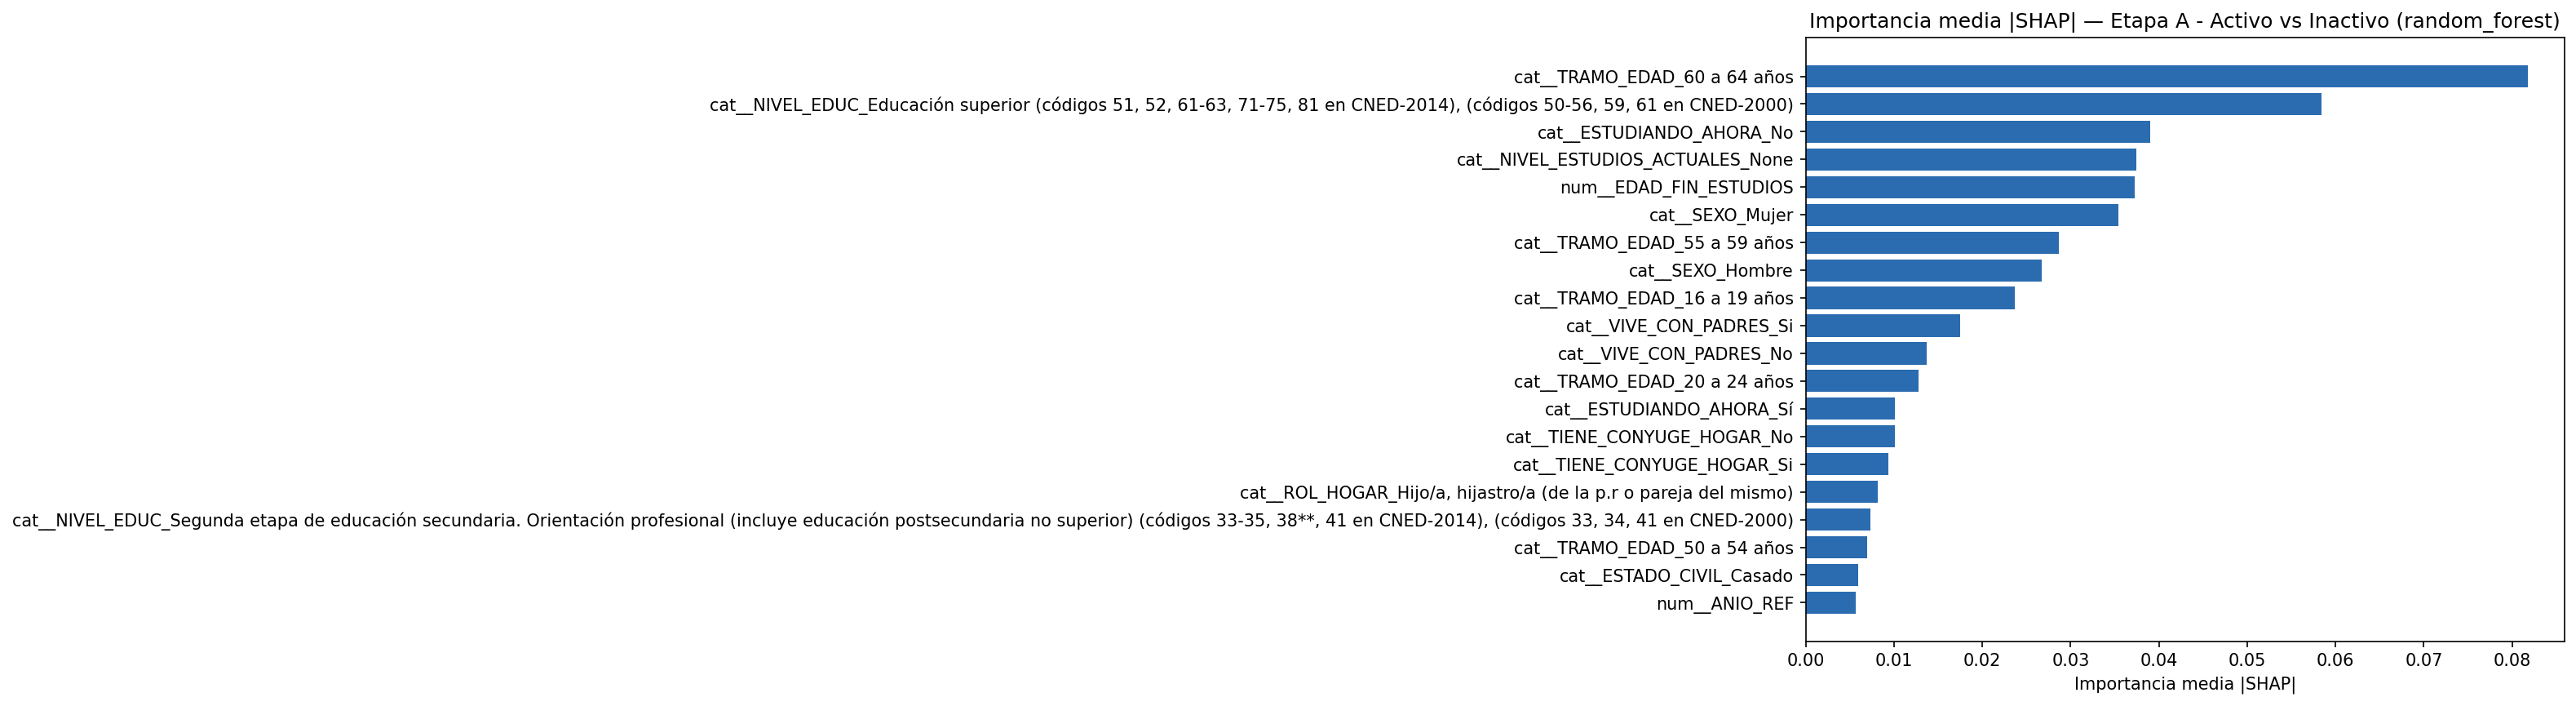

#### `etapa_b__ocupado_vs_parado_curva_pr.png`

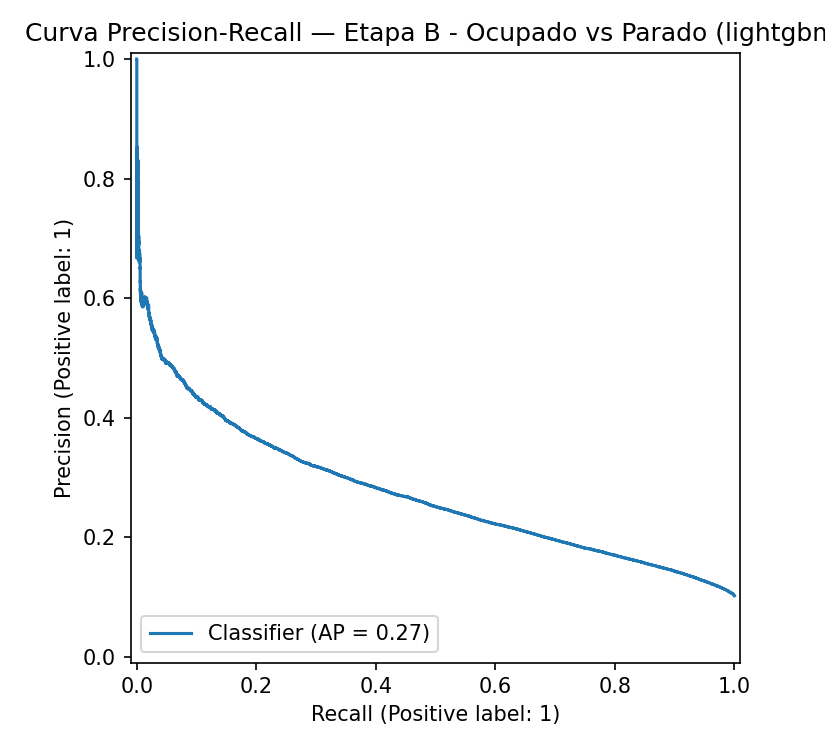

#### `etapa_b__ocupado_vs_parado_matriz_confusion.png`

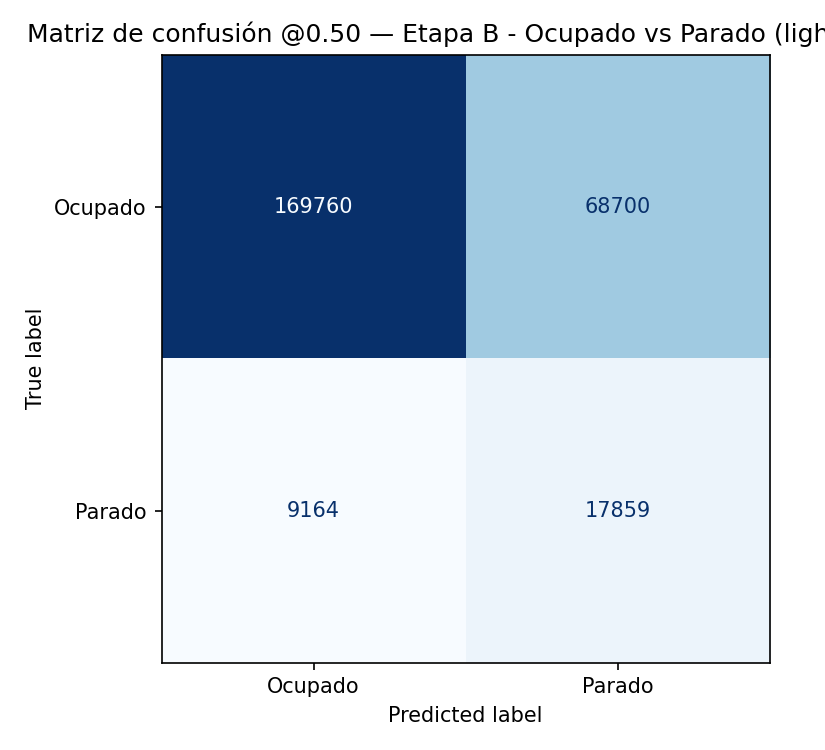

#### `etapa_b__ocupado_vs_parado_matriz_confusion_umbral_optimo.png`

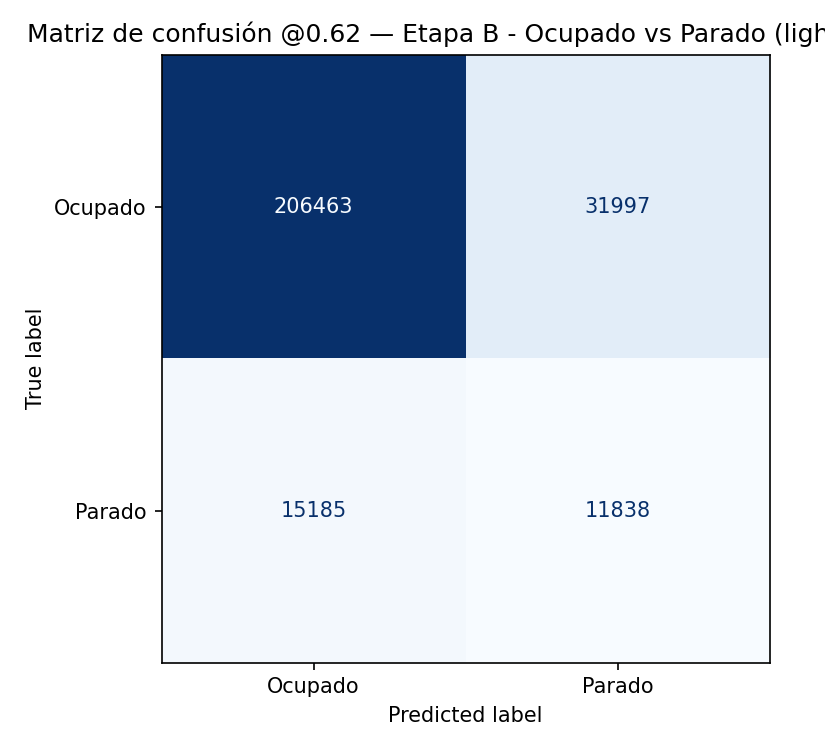

#### `etapa_b__ocupado_vs_parado_shap_summary.png`

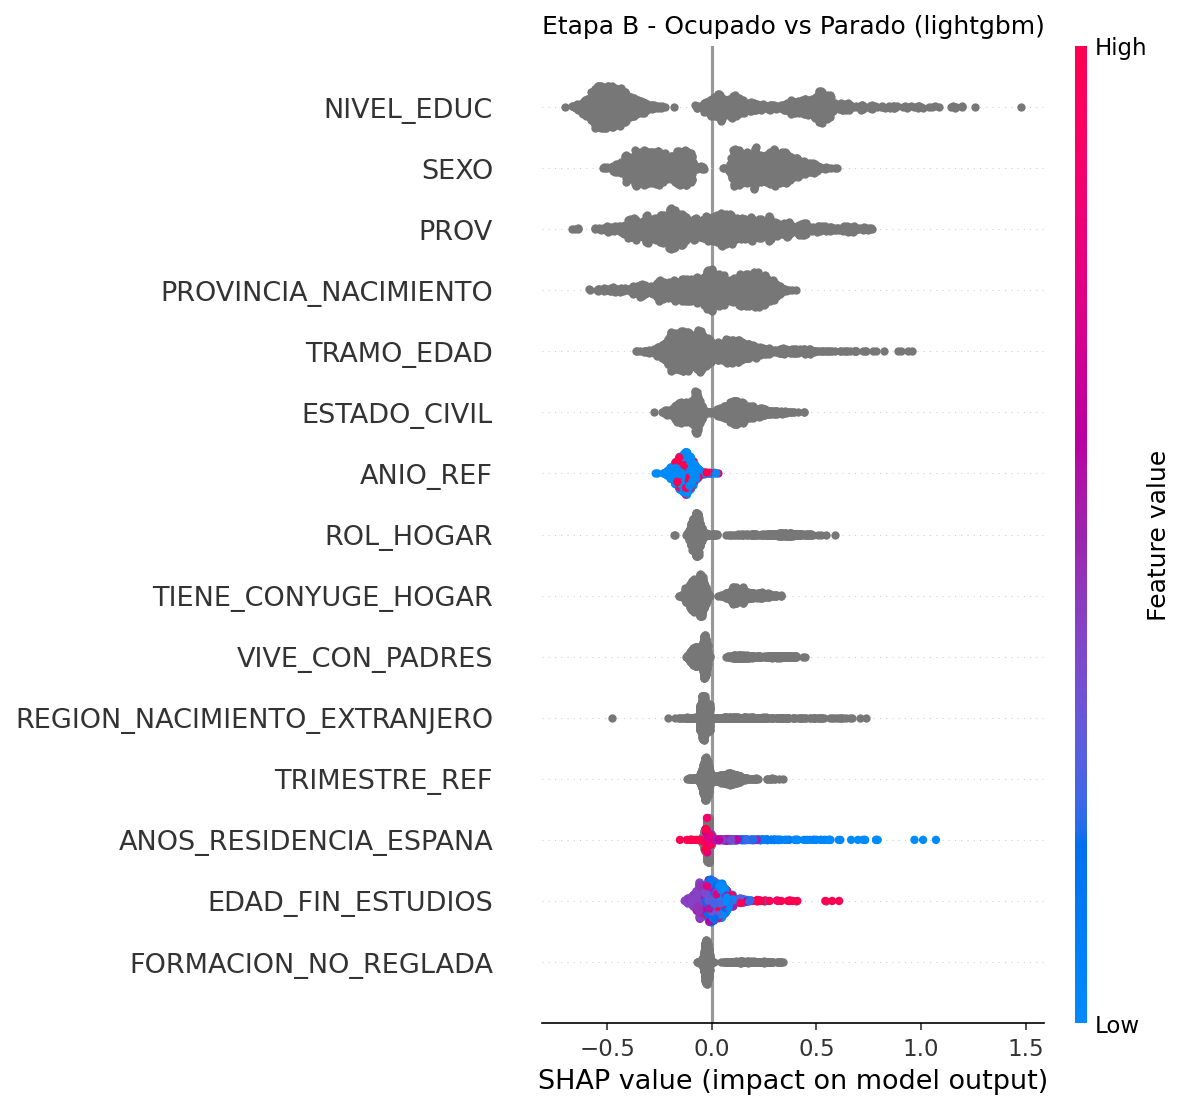

#### `etapa_b__ocupado_vs_parado_shap_importancia_barras.png`

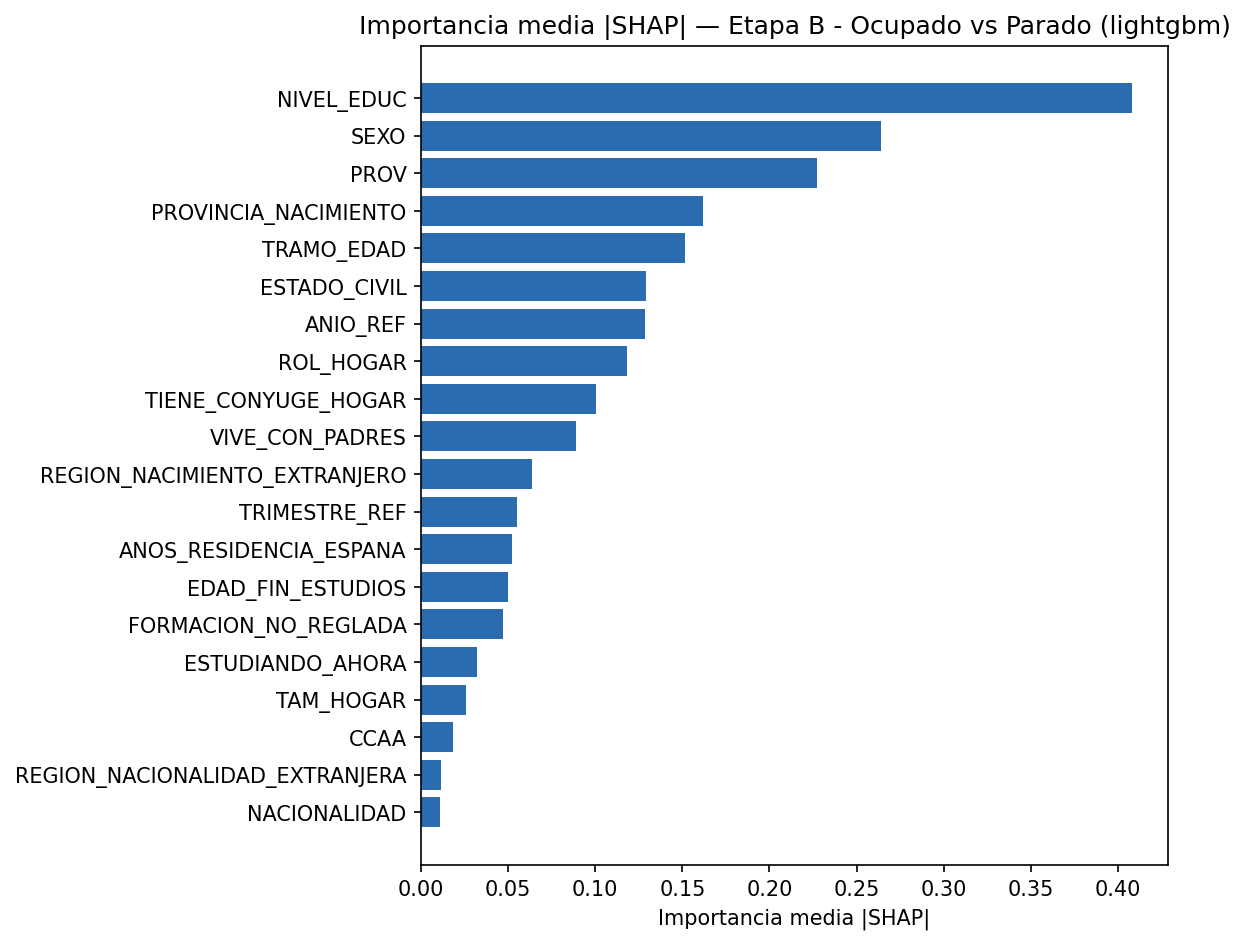

#### `combinado_matriz_confusion.png`

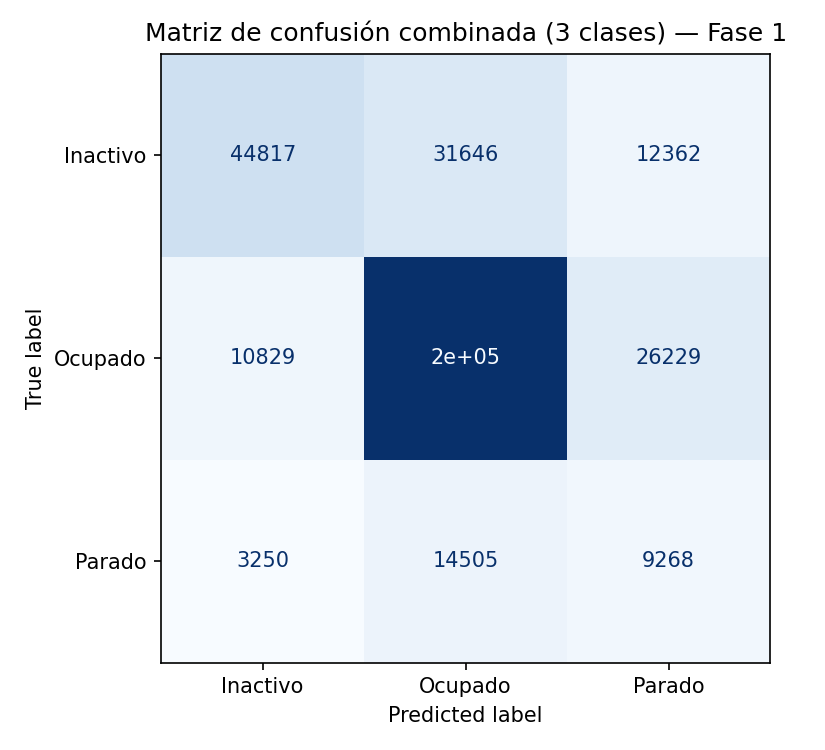

In [3]:
from IPython.display import Image, Markdown, display


def _mostrar_fig(path):
    if not path.exists():
        display(Markdown(f"*No encontrada:* `{path.relative_to(ROOT)}`"))
        return
    display(Markdown(f"#### `{path.name}`"))
    display(Image(data=path.read_bytes(), width=720))


# reports/figures/fase1

_mostrar_fig(ROOT / "reports/figures/fase1" / "etapa_a__activo_vs_inactivo_curva_pr.png")

_mostrar_fig(ROOT / "reports/figures/fase1" / "etapa_a__activo_vs_inactivo_matriz_confusion.png")

_mostrar_fig(ROOT / "reports/figures/fase1" / "etapa_a__activo_vs_inactivo_matriz_confusion_umbral_optimo.png")

_mostrar_fig(ROOT / "reports/figures/fase1" / "etapa_a__activo_vs_inactivo_shap_summary.png")

_mostrar_fig(ROOT / "reports/figures/fase1" / "etapa_a__activo_vs_inactivo_shap_importancia_barras.png")

_mostrar_fig(ROOT / "reports/figures/fase1" / "etapa_b__ocupado_vs_parado_curva_pr.png")

_mostrar_fig(ROOT / "reports/figures/fase1" / "etapa_b__ocupado_vs_parado_matriz_confusion.png")

_mostrar_fig(ROOT / "reports/figures/fase1" / "etapa_b__ocupado_vs_parado_matriz_confusion_umbral_optimo.png")

_mostrar_fig(ROOT / "reports/figures/fase1" / "etapa_b__ocupado_vs_parado_shap_summary.png")

_mostrar_fig(ROOT / "reports/figures/fase1" / "etapa_b__ocupado_vs_parado_shap_importancia_barras.png")

_mostrar_fig(ROOT / "reports/figures/fase1" / "combinado_matriz_confusion.png")


## 4. Decisiones de la Fase 1

| Decisión | Evidencia |
|---|---|
| Solo demografía en Fase 1 (anti-leakage) | Variables laborales excluidas; target macro no filtra al predictor |
| PR-AUC como métrica principal | Clases desbalanceadas (parado ≈ 9 %) |
| Umbrales F1 calibrados (A=0,275 · B=0,625) | Matrices @0,50 vs umbral óptimo |
| Etapa B no mejora mucho con más HP | LogReg, RF y LightGBM cercanos → techo informativo |
| Cascada A→B | Accuracy combinada ≈ 0,72; paro es la clase más difícil (F1 ≈ 0,25) |

Números y figuras de la Fase 1.
